In [1]:
import numpy as np
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from rdkit import Chem, DataStructs
from rdkit.Chem import (
    PandasTools,
    Draw,
    Descriptors,
    MACCSkeys,
    rdFingerprintGenerator,
    rdMolDescriptors
)

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [11]:
tr_df  = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\result\64\tr_df_64.csv")
val_df  = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\result\64\val_64.csv")
te_df  = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\result\64\te_df_64.csv")

In [12]:
te_df.head(1)

,Molecule ChEMBL ID,MIC,Units,Smiles,Label
0,CHEMBL4076166,64.0,ug.mL-1,CSc1ccc2c(c1)N(CCC1CCCCN1C(C)C)c1ccccc1S2,0


In [13]:
PandasTools.AddMoleculeColumnToFrame(tr_df, smilesCol="Smiles")
PandasTools.AddMoleculeColumnToFrame(val_df, smilesCol="Smiles")
PandasTools.AddMoleculeColumnToFrame(te_df, smilesCol="Smiles")

In [14]:
te_df.head(1)

,Molecule ChEMBL ID,MIC,Units,Smiles,Label,ROMol
0,CHEMBL4076166,64.0,ug.mL-1,CSc1ccc2c(c1)N(CCC1CCCCN1C(C)C)c1ccccc1S2,0,<rdkit.Chem.rdchem.Mol object at 0x00000146E2D...


Calculate molecular fingerprints

In [15]:
# get maccs FP
tr_df["maccs"] = tr_df.ROMol.apply(lambda m: MACCSkeys.GenMACCSKeys(m))
val_df["maccs"] = val_df.ROMol.apply(lambda m: MACCSkeys.GenMACCSKeys(m))
te_df["maccs"] = te_df.ROMol.apply(lambda m: MACCSkeys.GenMACCSKeys(m))

In [16]:
tr_maccs_df = pd.DataFrame([list(i.ToBitString()[1:]) for i in tr_df["maccs"]], columns=[f"MACCS_{i}" for i in range(166)])
val_maccs_df = pd.DataFrame([list(i.ToBitString()[1:]) for i in val_df["maccs"]], columns=[f"MACCS_{i}" for i in range(166)])
te_maccs_df = pd.DataFrame([list(i.ToBitString()[1:]) for i in te_df["maccs"]], columns=[f"MACCS_{i}" for i in range(166)])

In [17]:
X_train = np.array(tr_maccs_df)
X_val   = np.array(val_maccs_df)
X_test  = np.array(te_maccs_df)
X_test

array([['0', '0', '0', ..., '0', '1', '0'],
       ['0', '0', '0', ..., '1', '1', '0'],
       ['0', '0', '0', ..., '1', '1', '0'],
       ...,
       ['0', '0', '0', ..., '1', '1', '0'],
       ['0', '0', '0', ..., '1', '1', '0'],
       ['0', '0', '0', ..., '1', '1', '0']], dtype=object)

In [18]:
tsne_train = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne_train.fit_transform(X_train)

tsne_val = TSNE(n_components=2, random_state=42)
X_val_tsne = tsne_val.fit_transform(X_val)

tsne_test = TSNE(n_components=2, random_state=42)
X_test_tsne = tsne_test.fit_transform(X_test)

In [22]:
print(X_train_tsne.shape)
print(X_val_tsne.shape)
print(X_test_tsne.shape)

(10332, 2)
(1148, 2)
(1276, 2)


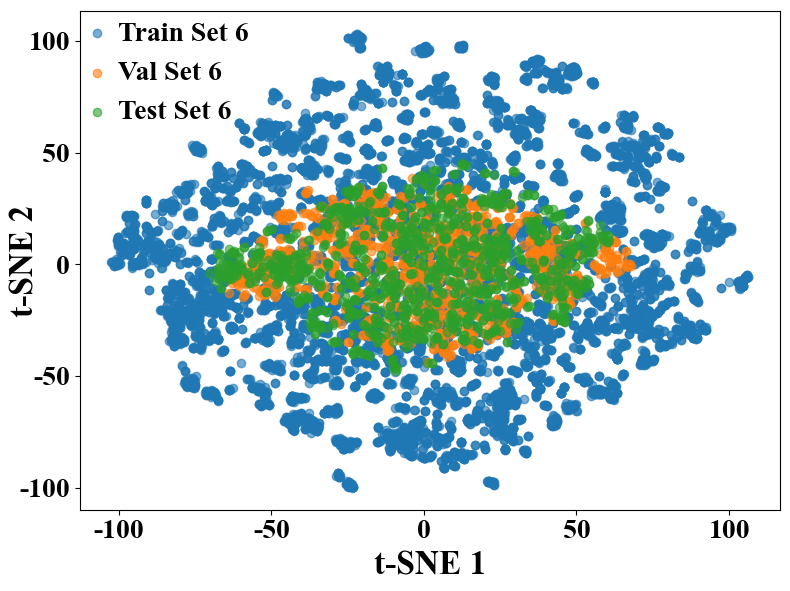

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_tsne[:,0], X_train_tsne[:,1], label="Train Set 6", alpha=0.6, color="#1f77b4")
plt.scatter(X_val_tsne[:,0], X_val_tsne[:,1], label="Val Set 6", alpha=0.6, color="#ff7f0e")
plt.scatter(X_test_tsne[:,0], X_test_tsne[:,1], label="Test Set 6", alpha=0.6, color="#2ca02c")

#plt.title("MACCS Fingerprint t-SNE Visualization", fontsize=28, pad=10, fontweight='bold') 
plt.xlabel("t-SNE 1", fontsize=24, fontweight='bold',labelpad=5)
plt.ylabel("t-SNE 2", fontsize=24, fontweight='bold',labelpad=-15)

plt.legend(prop={'size': 20, 'weight': 'bold'}, 
           frameon=False,
           loc='upper left',
           bbox_to_anchor=(-0.05, 1.03),
           handletextpad=-0.25)

x_ticks_values = [-100, -50, 0, 50, 100]
y_ticks_values = [-100, -50, 0, 50, 100]

plt.xticks(x_ticks_values,fontsize=20, weight='bold')
plt.yticks(y_ticks_values,fontsize=20, weight='bold')

plt.tight_layout()

plt.savefig("Chemical Space 64.pdf", format='pdf', bbox_inches='tight')

plt.show()